In [1]:
from dotenv import load_dotenv
import os

load_dotenv()

True

In [2]:
from langchain_tavily import TavilySearch

tool = TavilySearch()

# 直接调用工具
# .invoke() 方法是 LangChain Runnable 接口的标准执行方法
search_results = tool.invoke({"query": "What is LangGraph?"})

# 打印结果
import json

print(json.dumps(search_results, indent=2))

{
  "query": "What is LangGraph?",
  "follow_up_questions": null,
  "answer": null,
  "images": [],
  "results": [
    {
      "url": "https://www.geeksforgeeks.org/machine-learning/what-is-langgraph/",
      "title": "What is LangGraph",
      "content": "LangGraph is an open-source framework built by LangChain that streamlines the creation and management of AI agent workflows. At its core, LangGraph combines large language models (LLMs) with graph-based architectures allowing developers to map, organize and optimize how AI agents interact and make decisions. By treating workflows as interconnected nodes and edges, LangGraph offers a scalable, transparent and developer-friendly way to design advanced AI systems ranging from simple chatbots to multi-agent system. The diagram below shows how LangGraph structures its agent-based workflow using distinct tools and stages. By designing workflows, users combine multiple nodes into powerful, dynamic AI processes. * ****langgraph:**** Framewor

In [3]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model=os.getenv("OPENAI_MODEL", "gpt-4o-mini"),
    api_key=os.getenv("OPENAI_API_KEY"),
    base_url=os.getenv("OPENAI_BASE_URL"),
    temperature=0.2,  # 稳定输出
    timeout=1200,  # 超时保护（秒）
    max_retries=2,  # 简单重试
)

In [4]:
from langchain_tavily import TavilySearch

# 实例化Tavily搜索工具，设置返回结果数量为4
# 这是一个专为Agent设计的工具，能提供高质量的搜索结果
tool = TavilySearch(max_results=4)

# 将工具放入一个列表中，这是LangChain Agent的标准格式
tools = [tool]

print("Tool defined: TavilySearch")

Tool defined: TavilySearch


In [5]:
from typing import Annotated, TypedDict

class AgentState(TypedDict):
    # 用户的原始问题
    original_query: str
    # LLM规划后生成的子问题列表
    sub_queries: list[str]
    # 每个子问题对应的搜索结果
    # 结构为: {"sub_query_1": "results...", "sub_query_2": "results..."}
    search_results: dict[str, str]
    # 最终生成的报告
    final_report: str
    # LangGraph内部需要的消息历史
    messages: Annotated[list, lambda x, y: x + y]


print("Graph state 'AgentState' defined.")

Graph state 'AgentState' defined.


In [6]:
# --- 定义规划节点 (Planner Node) ---


def planner_node(state: AgentState):
    print("---进入规划节点---")
    # 准备一个格式化的提示，引导LLM进行任务拆解
    prompt = f"""你是一个世界级的AI研究助理。你的任务是接收一个复杂的研究问题，并将其分解为一系列更小、更具体的、可独立搜索的子问题。
    请为以下用户问题生成一个子问题列表，以便于进行网络搜索。每个子问题都应该是清晰、简洁的。

    用户问题: {state['original_query']}
    
    请返回一个仅包含子问题列表的JSON数组。
    例如: ["问题1", "问题2", "问题3"]
    """

    # 调用LLM生成子问题
    response = llm.invoke(prompt)
    sub_queries = json.loads(response.content)
    print(f"生成的子问题: {sub_queries}")

    # 更新状态
    return {"sub_queries": sub_queries}


# --- 定义研究节点 (Research Node) ---


def research_node(state: AgentState):
    print("---进入研究节点---")
    sub_queries = state.get("sub_queries", [])
    if not sub_queries:
        print("[research] 没有子问题可搜索，直接返回")
        return {"search_results": {}}

    # 【关键点1】batch 输入使用 {"query": "..."} 的列表，而不是纯字符串列表
    payload = [{"query": q} for q in sub_queries]

    try:
        # 【关键点2】指定并发，避免串行过慢；有的环境需要显式给 config
        results = tool.batch(payload, config={"max_concurrency": min(8, len(payload))})
        print(
            f"[research] batch 返回 {len(results)} 条结果，类型示例: {type(results[0]) if results else None}"
        )
    except Exception as e:
        print(f"[research] batch 调用异常，改用逐条 invoke。错误: {repr(e)}")
        results = []
        for q in sub_queries:
            try:
                r = tool.invoke({"query": q})  # 也可用 tool.invoke(q)
                results.append(r)
            except Exception as e2:
                results.append({"error": repr(e2)})

    # 结果归一化为字符串，便于写入状态
    norm = {}
    for q, r in zip(sub_queries, results):
        # r 可能是 dict / pydantic 模型 / 字符串，做一次尽量友好的提取
        try:
            if isinstance(r, dict) and "results" in r:
                # 只抽取前几条的 url + content，避免把 raw_content 带太多
                items = r.get("results", [])[:4]
                snippet = "\n".join(
                    [f"- {it.get('url')}: {it.get('content')}" for it in items]
                )
                norm[q] = snippet or str(r)
            else:
                norm[q] = str(r)
        except Exception:
            norm[q] = str(r)

    print("[research] 所有子问题搜索完成。")
    return {"search_results": norm}


# --- 定义撰写节点 (Writer Node) ---


def writer_node(state: AgentState):
    print("---进入撰写节点---")
    original_query = state["original_query"]
    search_results = state["search_results"]

    # 将所有搜索结果格式化，作为LLM的上下文
    context = "\n\n".join(
        [
            f"关于 '{query}' 的研究结果:\n{result}"
            for query, result in search_results.items()
        ]
    )

    prompt = f"""你是一个专业的AI报告撰写员。你的任务是根据提供的原始问题和一系列相关的研究资料，撰写一份全面、深入、结构清晰的研究报告。
    请确保报告逻辑连贯，并充分利用所有提供的资料。

    原始问题: {original_query}

    研究资料:
    {context}

    请根据以上信息，生成最终的研究报告。
    """

    # 调用LLM生成最终报告
    response = llm.invoke(prompt)
    print("最终报告生成完毕。")

    # 更新状态
    return {"final_report": response.content}


print("Graph nodes (planner, research, writer) defined.")

Graph nodes (planner, research, writer) defined.


In [7]:
from langgraph.graph import END, StateGraph

# 实例化StateGraph，并传入我们定义的状态类
workflow = StateGraph(AgentState)

# 添加节点到图中，每个节点都有一个唯一的名称
workflow.add_node("planner", planner_node)
workflow.add_node("researcher", research_node)
workflow.add_node("writer", writer_node)

# 设置图的入口点
workflow.set_entry_point("planner")

# 添加边，定义节点之间的连接关系
workflow.add_edge("planner", "researcher")
workflow.add_edge("researcher", "writer")

# 将撰写节点连接到图的终点
workflow.add_edge("writer", END)

# 编译图，生成一个可执行的Runnable对象
graph = workflow.compile()

print("Graph built and compiled successfully.")

Graph built and compiled successfully.


In [8]:
# 定义一个复杂的研究问题
query = "对比分析 LangChain 和 LangGraph 的主要区别及其各自的应用场景，并说明 LangGraph 为何更适合构建循环和有状态的 Agent。"

# 调用 graph.invoke() 来执行整个工作流
# 我们需要以字典形式传入初始状态，这里只需要提供原始问题
final_state = graph.invoke({"original_query": query})

# 打印最终生成的报告
from IPython.display import Markdown, display

display(Markdown(final_state["final_report"]))

---进入规划节点---
生成的子问题: ['LangChain和LangGraph的核心设计理念与架构有何区别？', 'LangChain的主要应用场景有哪些？', 'LangGraph的主要应用场景有哪些？', '什么是循环和有状态的Agent？为什么需要它们？', 'LangGraph如何支持循环和有状态的计算？', 'LangChain在构建循环和有状态Agent时存在哪些局限性？', 'LangChain与LangGraph在状态管理机制上有何差异？', 'LangGraph的图结构如何实现循环和条件分支？', '有哪些实际案例表明LangGraph比LangChain更适合构建循环和有状态的Agent？']
---进入研究节点---
[research] batch 返回 9 条结果，类型示例: <class 'dict'>
[research] 所有子问题搜索完成。
---进入撰写节点---
最终报告生成完毕。


# 对比分析 LangChain 与 LangGraph：设计理念、应用场景及循环有状态 Agent 构建优势

## 摘要

随着大语言模型（LLM）应用的快速发展，开发者需要更灵活、更强大的框架来构建复杂 AI 系统。LangChain 和 LangGraph 同属 LangChain 生态系统，但服务于不同层次的开发需求。本报告基于官方文档、技术博客及社区实践，系统对比了两者在核心设计理念、架构模式、状态管理、控制流等方面的差异，梳理了各自典型应用场景，并重点论证 LangGraph 在构建循环和有状态 Agent 方面的天然优势。研究表明，LangChain 作为组件库和线性工作流框架，适合快速搭建标准化的 LLM 应用；而 LangGraph 通过图结构、显式状态管理和循环支持，成为构建多智能体、自适应、可持久化的复杂 Agent 系统的首选。

---

## 1. 引言

在 LLM 应用开发领域，LangChain 率先提供了链式调用、工具集成、记忆管理等抽象层，极大降低了开发门槛。然而，随着 Agent 概念的兴起——尤其是需要自主决策、多步推理、错误恢复和长期记忆的场景——LangChain 的线性链式架构逐渐暴露出局限性。为此，LangChain 团队推出了 LangGraph，一个基于有向图（尤其是循环图）的框架，专门用于构建有状态、多参与者的复杂 Agent 工作流。两者并非替代关系，而是互补：LangChain 提供“积木”，LangGraph 决定“怎么搭”。本报告将深入剖析两者的区别，并阐明 LangGraph 在循环和有状态 Agent 构建中的核心价值。

---

## 2. LangChain 概述

### 2.1 设计理念与架构

LangChain 的核心设计理念是**组件化**和**链式编排**。它将 LLM 应用拆解为可复用的模块（如模型、提示模板、输出解析器、工具、记忆等），并通过 **LangChain 表达式语言（LCEL）** 以管道符 `|` 连接成线性或简单分支的工作流。其架构本质是**有向无环图（DAG）**，每一步的输出作为下一步的输入，流程单向、无循环。

### 2.2 主要应用场景

根据研究资料，LangChain 的典型应用包括：

- **内容生成**：电商产品描述、营销文案、角色扮演写作等。
- **智能客服**：基于 FAQ 的问答机器人，支持上下文记忆。
- **文档摘要与问答**：对长文档进行快速摘要或基于检索的问答（RAG）。
- **简单 Agent**：通过内置 Agent 类型（如 `ZERO_SHOT_REACT_DESCRIPTION`）实现“思考-行动-观察”循环，但受限于链式结构，难以处理复杂状态和多次迭代。

LangChain 的优势在于**快速原型开发**和**标准化流程**，适合线性、确定性高的任务。

---

## 3. LangGraph 概述

### 3.1 设计理念与架构

LangGraph 的设计灵感来源于 Pregel 和 Apache Beam，采用**有向图结构**，核心元素包括**节点（Node）**、**边（Edge）** 和**全局状态（State）**。节点代表计算单元（如 LLM 调用、工具执行），边定义节点间的数据流和控制流，状态则是一个在节点间传递的共享对象，记录所有中间变量。LangGraph 原生支持**循环边**和**条件边**，允许工作流根据当前状态动态决定下一步走向，甚至形成反馈回路。

### 3.2 主要应用场景

LangGraph 适用于需要**复杂控制流**和**持久化状态**的场景：

- **多智能体协作**：多个 Agent 共享状态，分工处理子任务（如电影场景创作、多角色对话模拟）。
- **增强型 RAG**：通过循环评估检索质量，若结果不佳则改进查询并重试，直至满意。
- **规划代理**：LLM 规划师分解任务，执行者调用工具，LLM 综合结果，支持动态调整计划。
- **人机协同（Human-in-the-Loop）**：在关键节点暂停，等待人类审核状态后再继续。
- **多模态代理**：整合文本、视觉等输入，如网页导航器。

---

## 4. 主要区别对比

| 维度 | LangChain | LangGraph |
|------|-----------|-----------|
| **核心架构** | 线性链 / DAG | 有向图（支持循环和条件分支） |
| **状态管理** | 依赖 Memory 组件（对话历史、外部存储），状态隐式传递 | 显式全局 State 对象，节点间共享，支持检查点（Checkpoint） |
| **控制流** | 预定义顺序或简单条件（通过 Router） | 条件边、循环边、动态路由，可自由定义图结构 |
| **循环支持** | 不支持原生循环，需外部 while 循环模拟 | 原生支持循环边，适合 ReAct 模式（推理→行动→观察→推理） |
| **持久化** | 需自行实现持久化（如数据库存储记忆） | 内置检查点机制，可暂停/恢复，支持错误恢复 |
| **可控性** | 高层抽象，易用但灵活性有限 | 低层控制，可精细定义节点行为、边逻辑、状态更新 |
| **与 LangChain 关系** | 独立框架，提供组件库 | 构建于 LangChain 之上，可复用其组件，也可独立使用 |

---

## 5. LangGraph 为何更适合构建循环和有状态的 Agent

### 5.1 循环支持：从“单程地铁”到“循环列车”

传统 Agent 的核心是“感知-决策-行动”循环。LangChain 的链式结构本质是单向的，若要实现循环，开发者必须手动编写 `while` 循环，并在每次迭代中重新组织输入输出，代码复杂且难以维护。LangGraph 则通过**循环边**直接建模这种迭代过程：节点 A（LLM 推理）→ 节点 B（工具执行）→ 条件边判断是否继续循环 → 若需要则返回节点 A。这种设计使得 ReAct 模式（推理→行动→观察→推理）的实现变得自然且简洁。

### 5.2 显式状态管理：从“参数传递”到“全局状态”

在 LangChain 中，数据通过函数参数在链的步骤间传递，状态（如对话历史、中间结果）需要依赖 Memory 组件，且跨步骤的共享不够直观。LangGraph 引入**全局 State 对象**，每个节点都可以读取和更新该对象。状态不仅包含用户输入和输出，还可存储工具调用结果、错误信息、决策历史等。这种设计使得：

- **错误恢复**：当某节点失败时，可从上一个检查点恢复状态，而非从头开始。
- **长期记忆**：通过检查点机制，状态可持久化到外部存储，实现跨会话记忆。
- **多 Agent 共享**：不同 Agent 节点可访问同一状态，协同完成任务。

### 5.3 持久性与“人在环”支持

LangGraph 内置 `InMemorySaver` 或 `SqliteSaver` 等检查点存储器，允许工作流在任意节点暂停、保存状态，并在后续恢复。这一特性直接支持：

- **Human-in-the-Loop**：在关键决策点暂停，等待人类审核当前状态，修改后继续执行。
- **长时间运行任务**：即使系统崩溃，也可从最近检查点恢复，避免重复计算。

### 5.4 条件分支与动态路由

LangGraph 的条件边允许根据当前状态（如 LLM 输出、工具结果）动态选择下一节点。例如，在 RAG 场景中，若检索结果置信度低，可路由到“查询重写”节点，形成循环优化。这种灵活性远超 LangChain 的静态链式结构。

### 5.5 实际案例佐证

- **多智能体客服系统**：使用 LangGraph 构建的客服 Agent 可同时处理订单查询、知识检索、转人工等任务，各子 Agent 共享用户会话状态，支持错误重试和人工介入。
- **自适应 RAG 管道**：传统 RAG 是线性流程，LangGraph 通过循环评估检索质量，若结果不佳则自动改进查询，显著提升准确率。
- **规划代理**：LLM 规划师制定计划后，执行者逐步执行，若某步失败，规划师可动态调整后续计划，形成闭环。

---

## 6. 选择建议

- **仅使用 LangChain**：当应用为线性流程、无复杂状态管理、无需循环时（如简单问答、文档摘要、内容生成），LangChain 更轻量、开发更快。
- **同时使用 LangChain 和 LangGraph**：当需要构建复杂 Agent（多智能体、循环推理、人机协同、持久化状态）时，建议以 LangGraph 作为编排框架，复用 LangChain 的模型、工具、记忆等组件，发挥各自优势。

---

## 7. 结论

LangChain 和 LangGraph 是 LangChain 生态中互补的两大工具。LangChain 提供了丰富的组件和便捷的链式编排，适合快速构建标准化 LLM 应用；LangGraph 则通过图结构、显式状态管理和原生循环支持，解决了 LangChain 在复杂 Agent 场景下的根本局限。对于需要循环推理、状态持久化、多智能体协作或人机协同的现代 AI 系统，LangGraph 是更合适的选择。开发者应根据实际需求灵活组合两者，以构建高效、可靠、可扩展的智能应用。

---

**参考文献**

[1] LangChain 与 LangGraph 核心设计理念对比，知乎专栏.  
[2] LangGraph 官方文档及教程，LangChain AI.  
[3] LangChain 应用场景分析，CSDN 博客.  
[4] LangGraph 多智能体工作流实践，腾讯云开发者社区.  
[5] 循环与有状态 Agent 原理，知乎专栏.  
[6] LangGraph 状态管理与持久化机制，飞书文档.  
[7] LangChain vs LangGraph 实际案例对比，CSDN 博客.

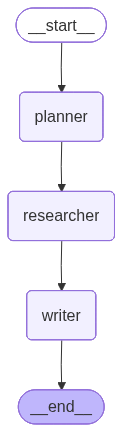

In [9]:
from IPython.display import Image

try:
    # 生成并显示图的可视化PNG图片
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"无法生成可视化图片，请确保已安装pygraphviz和graphviz: {e}")